#  Functional API
Hier ist ein vollständiges Beispiel. Wir nutzen die Functional API, um eine Skip Connection (wie in **ResNet**) zu bauen, setzen eigene Gewichte und lassen ein Bild durchlaufen.

In [2]:
import numpy as np
import tensorflow as tf
from keras import layers, models

# 1. Modell definieren (Functional API mit Skip Connection)
inputs = layers.Input(shape=(9, 9, 3), name="input")

# Hauptpfad: Eine Faltung, die die Form erhält (padding='same')
conv_layer = layers.Conv2D(filters=3, kernel_size=(3,3), padding='same', use_bias=False, name="conv")
x = conv_layer(inputs)
print("x.shape:", x.shape)
print("x.type:", type(x))

# Skip Connection: Wir addieren den ursprünglichen Input zum Ergebnis der Faltung
# Das geht nur, wenn die Dimensionen (9,9,3) exakt gleich bleiben
added = layers.Add(name="residual_sum")([x, inputs])

model = models.Model(inputs=inputs, outputs=added)

# 2. Simulationsdaten erstellen (Ein Batch mit einem 9x9x3 Bild)
# Format: (Batch, Höhe, Breite, Kanäle)
x_sim = np.random.rand(1, 9, 9, 3).astype(np.float32)

# 3. Gewichte manuell setzen (optional, sonst Zufall)
# Form für Keras Conv2D: (H, W, In, Out) -> hier (3, 3, 3, 3)
custom_kernel = np.ones((3, 3, 3, 3), dtype=np.float32) * 0.1
conv_layer.set_weights([custom_kernel])

# 4. Vorhersage (Prediction)
output = model.predict(x_sim)

print(f"Input Form:  {x_sim.shape}")
print(f"Output Form: {output.shape}")
print("\nErgebnis der Addition (erste 2x2 Pixel des ersten Kanals):")
print(output[0, :2, :2, 0])


x.shape: (None, 9, 9, 3)
x.type: <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Input Form:  (1, 9, 9, 3)
Output Form: (1, 9, 9, 3)

Ergebnis der Addition (erste 2x2 Pixel des ersten Kanals):
[[1.2223964 1.2166427]
 [1.3938297 2.1624842]]


In [3]:
#!pip install pydot

C:\0_DA\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
pydot gefunden: C:\0_DA\Python312\Lib\site-packages\pydot\__init__.py


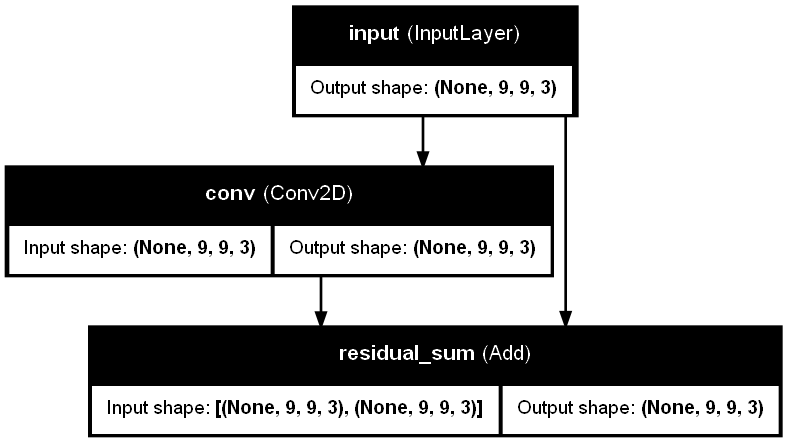

In [4]:
#from keras.utils import plot_model
from tensorflow.keras.utils import plot_model
import sys, subprocess, pkgutil

print(sys.executable)                 # Zeigt den Python-Pfad des Jupyter-Kernels
print(sys.version)

# Prüfen, ob pydot im Kernel wirklich verfügbar ist
import importlib
try:
    pydot = importlib.import_module("pydot")
    print("pydot gefunden:", pydot.__file__)
except ImportError as e:
    print("pydot NICHT gefunden:", e)

# Testweise pip im Kernel-Kontext verwenden
subprocess.run([sys.executable, "-m", "pip", "show", "pydot"])


# Visualisierung erstellen
plot_model(
    model, 
    to_file='model_architektur.png', 
    show_shapes=True,           # Zeigt die Dimensionen der Tensoren (z.B. 9x9x3)
    show_layer_names=True,      # Zeigt die Namen der Layer an
    rankdir='TB',               # 'TB' für Top-to-Bottom (vertikal), 'LR' für horizontal
    dpi=96                      # Bildauflösung
)
